In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer, load_wine, load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Carregando bases nativas...")
datasets = {
    "1. Iris": (load_iris().data, load_iris().target),
    "2. Breast Cancer": (load_breast_cancer().data, load_breast_cancer().target),
    "3. Wine": (load_wine().data, load_wine().target),
    "4. Digits": (load_digits().data, load_digits().target)
}

print("Baixando Base 5: Heart Disease direto da UCI...")
url_heart = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
col_names_heart = [f"f{i}" for i in range(13)] + ["target"]
df_heart = pd.read_csv(url_heart, names=col_names_heart, na_values="?")
df_heart = df_heart.dropna() # Remove linhas com valores nulos (?)
X_heart = df_heart.drop("target", axis=1).values
y_heart = df_heart["target"].apply(lambda x: 1 if x > 0 else 0).values # Transforma em classificação binária (Saudável vs Doente)
datasets["5. Heart Disease"] = (X_heart, y_heart)

print("Baixando Base 6: Seeds direto da UCI...")
url_seeds = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
# O arquivo de seeds usa múltiplos espaços ou abas como separador
df_seeds = pd.read_csv(url_seeds, sep=r'\s+', names=[f"f{i}" for i in range(7)] + ["target"])
X_seeds = df_seeds.drop("target", axis=1).values
y_seeds = df_seeds["target"].values - 1 # Ajusta classes para começar em 0
datasets["6. Seeds"] = (X_seeds, y_seeds)

# Lista para guardar seus resultados estruturados
meus_resultados = []
print("\nTodas as 6 bases de dados foram carregadas com sucesso!")

Carregando bases nativas...
Baixando Base 5: Heart Disease direto da UCI...
Baixando Base 6: Seeds direto da UCI...

Todas as 6 bases de dados foram carregadas com sucesso!


In [ ]:
def otimizar_seu_knn(X_train, X_test, y_train, y_test, nome_da_base):
    """Testa variações de K e gera o gráfico de linha de acurácia."""
    valores_k = range(1, 16)
    acuracias = []

    for k in valores_k:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acuracias.append(accuracy_score(y_test, y_pred))

    # Gerando o gráfico de linha
    plt.figure(figsize=(7, 3.5))
    plt.plot(valores_k, acuracias, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
    plt.title(f'Curva de Otimização do K - {nome_da_base}', fontsize=12, fontweight='bold')
    plt.xlabel('Valor de K (Vizinhos)', fontsize=10)
    plt.ylabel('Acurácia no Teste', fontsize=10)
    plt.xticks(valores_k)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Identifica o K de melhor desempenho
    melhor_k = valores_k[np.argmax(acuracias)]
    print(f"-> [Resultado KNN]: O melhor valor de K para '{nome_da_base}' é K = {melhor_k}\n")
    return melhor_k


PROCESSANDO: 1. Iris


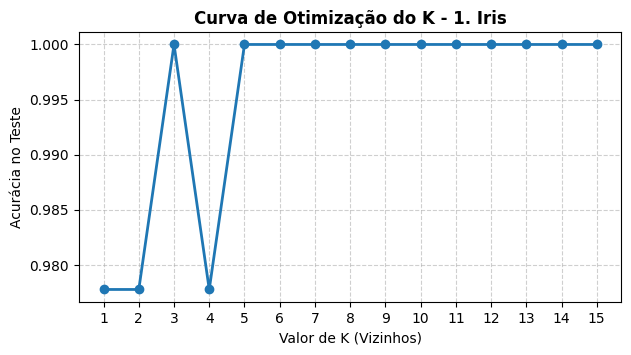

-> [Resultado KNN]: O melhor valor de K para '1. Iris' é K = 3



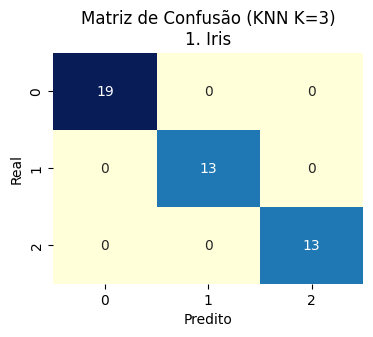


PROCESSANDO: 2. Breast Cancer


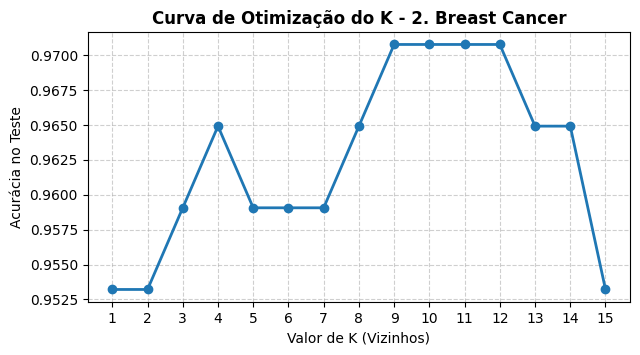

-> [Resultado KNN]: O melhor valor de K para '2. Breast Cancer' é K = 9



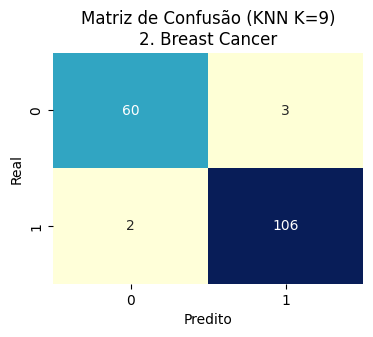


PROCESSANDO: 3. Wine


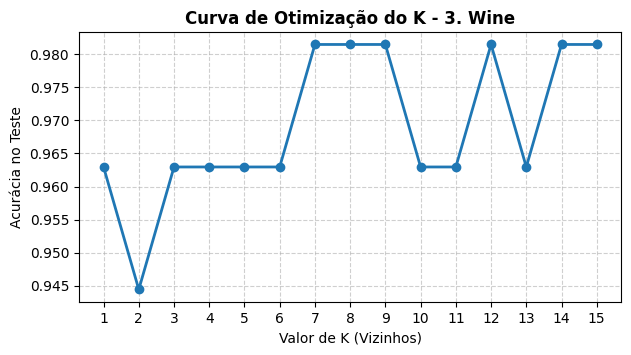

-> [Resultado KNN]: O melhor valor de K para '3. Wine' é K = 7



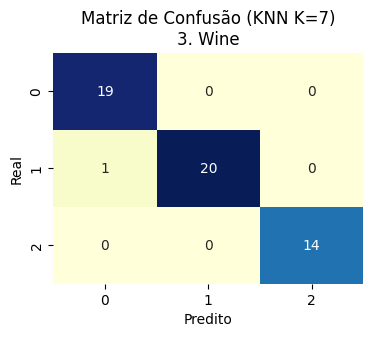


PROCESSANDO: 4. Digits


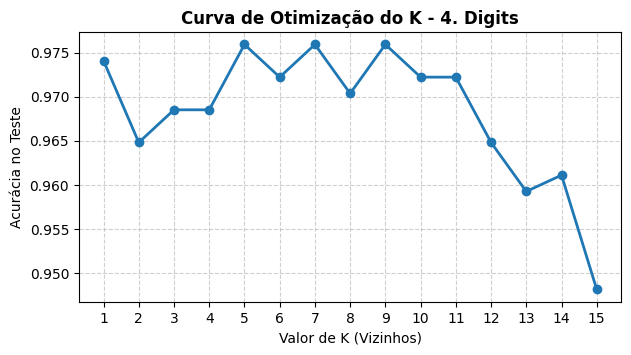

-> [Resultado KNN]: O melhor valor de K para '4. Digits' é K = 5



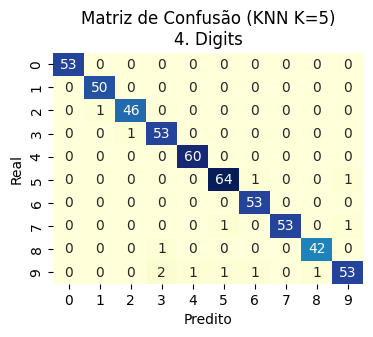


PROCESSANDO: 5. Heart Disease


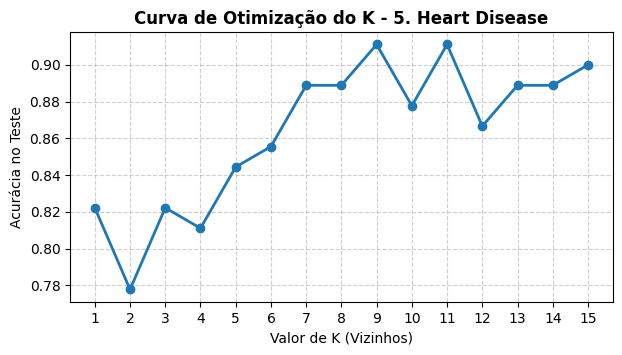

-> [Resultado KNN]: O melhor valor de K para '5. Heart Disease' é K = 9



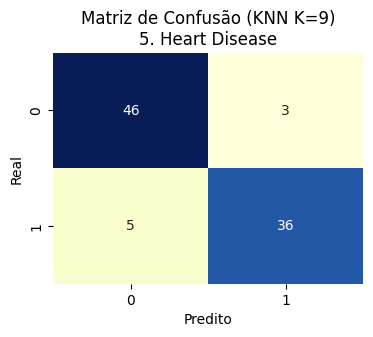


PROCESSANDO: 6. Seeds


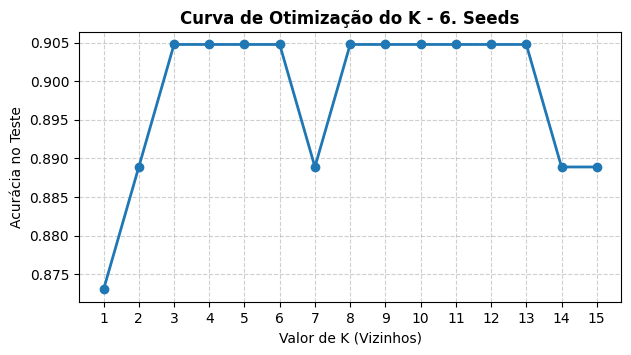

-> [Resultado KNN]: O melhor valor de K para '6. Seeds' é K = 3



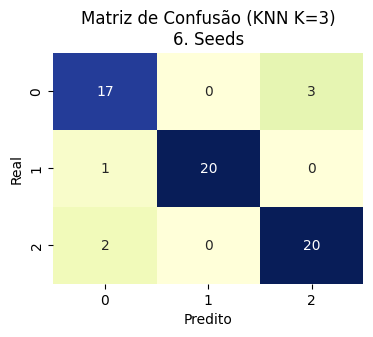

In [ ]:
for nome_da_base, (X, y) in datasets.items():
    print(f"\n{'='*60}\nPROCESSANDO: {nome_da_base}\n{'='*60}")

    # Divisão treino/teste (70% / 30%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Normalização dos dados (Fundamental para algoritmos de distância como KNN)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Encontra o K ótimo usando a função do Bloco 2
    k_ideal = otimizar_seu_knn(X_train_scaled, X_test_scaled, y_train, y_test, nome_da_base)

    # Treina o modelo final com o K ideal
    knn_final = KNeighborsClassifier(n_neighbors=k_ideal)
    knn_final.fit(X_train_scaled, y_train)

    # Predição
    y_pred = knn_final.predict(X_test_scaled)

    # Extração das Métricas solicitadas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Armazena no dicionário global
    meus_resultados.append({
        "Base de Dados": nome_da_base,
        "Melhor K": k_ideal,
        "Acurácia": acc,
        "Precisão": prec,
        "Revocação": rec,
        "F1-Score": f1
    })

    # Plota a Matriz de Confusão do seu modelo
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
    plt.title(f'Matriz de Confusão (KNN K={k_ideal})\n{nome_da_base}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

In [ ]:
df_meus_resultados = pd.DataFrame(meus_resultados)
print("\n" + "="*50)
print("TABELA DE MÉTRICAS DO SEU ALGORITMO (KNN)")
print("="*50)
display(df_meus_resultados)


TABELA DE MÉTRICAS DO SEU ALGORITMO (KNN)


,Base de Dados,Melhor K,Acurácia,Precisão,Revocação,F1-Score
0,1. Iris,3,1.000000,1.000000,1.000000,1.000000
1,2. Breast Cancer,9,0.970760,0.970733,0.970760,0.970711
2,3. Wine,7,0.981481,0.982407,0.981481,0.981493
3,4. Digits,5,0.975926,0.976056,0.975926,0.975750
4,5. Heart Disease,9,0.911111,0.911580,0.911111,0.910889
5,6. Seeds,3,0.904762,0.906832,0.904762,0.905450
